# NHANES Data Assembly Pipeline

**Repository:** ML for Nutrition Research  
**Output:** `MLforNutrition_NHANES.csv` — the single dataset loaded by all tutorials in this repository.

This notebook downloads raw XPT files from the CDC NHANES public data portal for survey
cycles 1999–2018, merges demographic, examination, dietary, and laboratory components,
applies inclusion criteria, imputes missing anthropometric and blood pressure values, and
derives the binary outcome variables used across the ML tutorials.

---

## Inclusion Criteria

| Criterion | Decision |
|---|---|
| Age | Adults only (≥ 18 years) |
| Dietary data | Complete Day 1 24-hour dietary recall required |
| Fasting labs | Glucose, HDL, and triglycerides all required (fasting subsample only) |
| Diastolic BP | Must be > 1 mmHg (removes physiologically implausible values) |

## Missingness Strategy

| Category | Variables | Strategy |
|---|---|---|
| Fasting labs | `glucose`, `hdl`, `triglycerides` | Listwise deletion — missing by survey design, not at random |
| Dietary recall | `kcal`, `protein`, `carb`, `fat_*`, `sugar` | Listwise deletion — NHANES guidance advises against imputation |
| Anthropometrics + BP | `weight`, `height`, `bmi`, `waist`, `bp_sys`, `bp_di` | Multiple imputation (MICE via scikit-learn `IterativeImputer`) |

## Derived Outcome Variables

Six binary outcome variables are computed using established clinical thresholds
(ATP III / AHA–ACC 2017). See Section 11 for exact definitions and citations.

---
## Section 1: Library Imports

In [1]:
import os
import time
import requests
import numpy as np
import pandas as pd
from functools import reduce
from tqdm import tqdm

pd.set_option("display.max_columns", 200)

---
## Section 2: Survey Cycle Configuration

NHANES releases data in two-year cycles. Each cycle appends a letter suffix to file names
(e.g., `DEMO_J` for 2017–2018). Three components — HDL, triglycerides, and fasting glucose —
used non-standard lab file names in early cycles (1999–2004) that require explicit mapping.

In [2]:
# Cycle suffix letters: empty string for 1999-2000; B through J thereafter
CYCLE_LETTER = {
    1999: "",   # 1999-2000
    2001: "B",  # 2001-2002
    2003: "C",  # 2003-2004
    2005: "D",  # 2005-2006
    2007: "E",  # 2007-2008
    2009: "F",  # 2009-2010
    2011: "G",  # 2011-2012
    2013: "H",  # 2013-2014
    2015: "I",  # 2015-2016
    2017: "J",  # 2017-2018
}

def lbl(base: str, year: int) -> str:
    """Return the NHANES file label for a given component and cycle year."""
    suf = CYCLE_LETTER[year]
    return f"{base}_{suf}" if suf else base

def files_for_cycle(year: int) -> dict:
    """
    Return a dictionary mapping component keys to NHANES file labels for a given
    cycle start year. Handles naming conventions that changed across cycles for
    the dietary, HDL, triglyceride, and glucose files.
    """
    # Dietary totals: 1999 and 2001 use DRXTOT; later cycles use DR1TOT (Day 1 only)
    if year in (1999, 2001):
        diet_labels = ["DRXTOT" if year == 1999 else f"DRXTOT_{CYCLE_LETTER[year]}"]
    else:
        diet_labels = [f"DR1TOT_{CYCLE_LETTER[year]}"]

    # HDL: non-standard lab file names for 1999-2004
    if year == 1999:
        hdl_label = "LAB13"
    elif year == 2001:
        hdl_label = "L13_B"
    elif year == 2003:
        hdl_label = "L13_C"
    else:
        hdl_label = lbl("HDL", year)

    # Triglycerides: non-standard for 1999-2004
    if year == 1999:
        trig_label = "LAB13AM"
    elif year == 2001:
        trig_label = "L13AM_B"
    elif year == 2003:
        trig_label = "L13AM_C"
    else:
        trig_label = lbl("TRIGLY", year)

    # Fasting glucose: non-standard for 1999-2004
    if year == 1999:
        glu_label = "LAB10AM"
    elif year == 2001:
        glu_label = "L10AM_B"
    elif year == 2003:
        glu_label = "L10AM_C"
    else:
        glu_label = lbl("GLU", year)

    return dict(
        DEMO=lbl("DEMO", year),
        BMX=lbl("BMX", year),
        BPX=lbl("BPX", year),
        DIET=diet_labels,
        HDL=hdl_label,
        TRIG=trig_label,
        GLU=glu_label,
        BPQ=lbl("BPQ", year),
    )

ALL_CYCLES = sorted(CYCLE_LETTER.keys())

# Verification: confirm expected file labels per cycle for the three non-standard components
from collections import OrderedDict
preview = OrderedDict()
for yr in sorted(CYCLE_LETTER):
    f = files_for_cycle(yr)
    preview[(yr, "HDL")]  = f["HDL"]
    preview[(yr, "TRIG")] = f["TRIG"]
    preview[(yr, "GLU")]  = f["GLU"]
preview

OrderedDict([((1999, 'HDL'), 'LAB13'),
             ((1999, 'TRIG'), 'LAB13AM'),
             ((1999, 'GLU'), 'LAB10AM'),
             ((2001, 'HDL'), 'L13_B'),
             ((2001, 'TRIG'), 'L13AM_B'),
             ((2001, 'GLU'), 'L10AM_B'),
             ((2003, 'HDL'), 'L13_C'),
             ((2003, 'TRIG'), 'L13AM_C'),
             ((2003, 'GLU'), 'L10AM_C'),
             ((2005, 'HDL'), 'HDL_D'),
             ((2005, 'TRIG'), 'TRIGLY_D'),
             ((2005, 'GLU'), 'GLU_D'),
             ((2007, 'HDL'), 'HDL_E'),
             ((2007, 'TRIG'), 'TRIGLY_E'),
             ((2007, 'GLU'), 'GLU_E'),
             ((2009, 'HDL'), 'HDL_F'),
             ((2009, 'TRIG'), 'TRIGLY_F'),
             ((2009, 'GLU'), 'GLU_F'),
             ((2011, 'HDL'), 'HDL_G'),
             ((2011, 'TRIG'), 'TRIGLY_G'),
             ((2011, 'GLU'), 'GLU_G'),
             ((2013, 'HDL'), 'HDL_H'),
             ((2013, 'TRIG'), 'TRIGLY_H'),
             ((2013, 'GLU'), 'GLU_H'),
             ((2015, 'HDL'), 

---
## Section 3: Download XPT Files

XPT files are downloaded from the CDC NHANES public portal and cached locally.
Re-running this section will skip files that are already cached.

In [3]:
BASE_URL = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{year}/DataFiles/{label}.xpt"
XPT_DIR  = "nhanes_xpt_1999_2018"
os.makedirs(XPT_DIR, exist_ok=True)

def fetch_xpt(year: int, label: str, retries: int = 3, backoff: float = 2.0) -> str:
    """
    Download a single NHANES XPT file to the local cache directory.
    Returns the local file path. Skips download if a valid cached copy exists.

    Parameters
    ----------
    year    : Survey cycle start year.
    label   : NHANES file label (e.g., 'DEMO_J').
    retries : Number of download attempts before raising an error.
    backoff : Base delay (seconds) between retries; multiplied by attempt number.
    """
    url  = BASE_URL.format(year=year, label=label)
    dest = os.path.join(XPT_DIR, f"{label}.xpt")
    if os.path.exists(dest) and os.path.getsize(dest) > 1024:
        return dest  # Already cached
    for attempt in range(1, retries + 1):
        r = requests.get(url, timeout=60)
        if r.ok and len(r.content) > 1024:
            with open(dest, "wb") as fh:
                fh.write(r.content)
            return dest
        time.sleep(backoff * attempt)
    raise RuntimeError(f"Failed to fetch {label} ({year}) after {retries} attempts. URL: {url}")

# Download all required XPT files across all cycles
download_manifest = []
for yr in tqdm(ALL_CYCLES, desc="Downloading XPT files"):
    files = files_for_cycle(yr)
    for key in ["DEMO", "BMX", "BPX", "HDL", "TRIG", "GLU", "BPQ"]:
        path = fetch_xpt(yr, files[key])
        download_manifest.append(dict(year=yr, component=key, label=files[key], path=path))
    for label in files["DIET"]:
        path = fetch_xpt(yr, label)
        download_manifest.append(dict(year=yr, component="DIET", label=label, path=path))

print(f"Total XPT files cached: {len(download_manifest)}")

Total XPT files cached: 80


---
## Section 4: Load XPT Files and Select Columns

Each XPT file is read and immediately subsetted to only the columns needed.
Lab files (HDL, glucose, triglycerides) changed column names across cycles;
a candidate-mapping approach standardizes them to a single target name per variable.

In [4]:
def read_xpt(path: str) -> pd.DataFrame:
    """Read a SAS XPT file into a pandas DataFrame."""
    return pd.read_sas(path, format="xport", encoding="latin-1")

# Target column lists per component
KEEP_DEMO      = ["SEQN", "RIDAGEYR", "RIAGENDR"]
KEEP_BMX       = ["SEQN", "BMXWT", "BMXHT", "BMXBMI", "BMXWAIST"]
KEEP_BPX       = ["SEQN", "BPXSY1", "BPXDI1"]
KEEP_BPQ       = ["SEQN", "BPQ050A", "BPQ100D"]
KEEP_DIET_DAY1 = ["SEQN", "DR1TKCAL", "DR1TPROT", "DR1TSUGR", "DR1TCARB",
                   "DR1TTFAT", "DR1TSFAT", "DR1TMFAT", "DR1TPFAT"]
KEEP_DIET_DRXT = ["SEQN", "DRXTKCAL", "DRXTPROT",
                   "DRXTSUGR", "DRXTSUGR1", "DRXTSUGR2",
                   "DRXTCARB", "DRXTTFAT", "DRXTSFAT", "DRXTMFAT", "DRXTPFAT"]

# Candidate source→standardized-name mappings for lab variables
CANDIDATE_MAPS = {
    "HDL":  [("LBDHDD", "LBDHDD"), ("LBDHDL", "LBDHDD"), ("LBXHDD", "LBDHDD"), ("LBXHDL", "LBDHDD")],
    "GLU":  [("LBXGLU", "LBXGLU"), ("LBXGLU1", "LBXGLU")],
    "TRIG": [("LBXTR", "LBXTR"),   ("LBDTRSI", "LBXTR")],
}

def pick_and_standardize(df: pd.DataFrame, candidates: list) -> tuple:
    """
    Select the first available source column from the candidates list,
    rename it to the standardized target name, and return the subset.
    Returns (SEQN + standardized column, source name used).
    If no candidate is found, returns (SEQN-only frame, None).
    """
    for src, std in candidates:
        if src in df.columns:
            return df[["SEQN", src]].rename(columns={src: std}), src
    return df[["SEQN"]].copy(), None

# Load and subset each component for every cycle
cycle_frames      = []
column_source_log = []  # Audit trail: which source column was used per lab per cycle

for yr in tqdm(ALL_CYCLES, desc="Loading and selecting columns"):
    files = files_for_cycle(yr)

    demo_raw = read_xpt(fetch_xpt(yr, files["DEMO"]))
    bmx_raw  = read_xpt(fetch_xpt(yr, files["BMX"]))
    bpx_raw  = read_xpt(fetch_xpt(yr, files["BPX"]))
    bpq_raw  = read_xpt(fetch_xpt(yr, files["BPQ"]))

    demo = demo_raw[[c for c in KEEP_DEMO if c in demo_raw.columns]]
    bmx  = bmx_raw [[c for c in KEEP_BMX  if c in bmx_raw.columns]]
    bpx  = bpx_raw [[c for c in KEEP_BPX  if c in bpx_raw.columns]]
    bpq  = bpq_raw [[c for c in KEEP_BPQ  if c in bpq_raw.columns]]

    # Dietary totals: prefer DR1T* (Day 1); map DRXT* for 1999-2001
    diet_label = files["DIET"][0]
    diet_df    = read_xpt(fetch_xpt(yr, diet_label))
    has_day1   = any(c in diet_df.columns for c in KEEP_DIET_DAY1 if c != "SEQN")
    has_drxt   = any(c in diet_df.columns for c in KEEP_DIET_DRXT if c != "SEQN")

    if has_day1:
        diet = diet_df[[c for c in KEEP_DIET_DAY1 if c in diet_df.columns]]
    elif has_drxt:
        diet = diet_df[[c for c in KEEP_DIET_DRXT if c in diet_df.columns]].rename(columns={
            "DRXTKCAL": "DR1TKCAL", "DRXTPROT": "DR1TPROT",
            "DRXTSUGR": "DR1TSUGR", "DRXTSUGR1": "DR1TSUGR", "DRXTSUGR2": "DR1TSUGR",
            "DRXTCARB": "DR1TCARB", "DRXTTFAT": "DR1TTFAT",
            "DRXTSFAT": "DR1TSFAT", "DRXTMFAT": "DR1TMFAT", "DRXTPFAT": "DR1TPFAT",
        })
    else:
        raise KeyError(f"No recognized dietary columns found for {yr} in {diet_label}.")

    # Standardize lab column names
    hdl_raw  = read_xpt(fetch_xpt(yr, files["HDL"]))
    hdl,  hdl_src  = pick_and_standardize(hdl_raw,  CANDIDATE_MAPS["HDL"])
    column_source_log.append((yr, "HDL",  files["HDL"],  hdl_src  or "NOT_FOUND"))

    glu_raw  = read_xpt(fetch_xpt(yr, files["GLU"]))
    glu,  glu_src  = pick_and_standardize(glu_raw,  CANDIDATE_MAPS["GLU"])
    column_source_log.append((yr, "GLU",  files["GLU"],  glu_src  or "NOT_FOUND"))

    trig_raw = read_xpt(fetch_xpt(yr, files["TRIG"]))
    trig, trig_src = pick_and_standardize(trig_raw, CANDIDATE_MAPS["TRIG"])
    column_source_log.append((yr, "TRIG", files["TRIG"], trig_src or "NOT_FOUND"))

    # Merge all components for this cycle (left joins anchored to DEMO)
    pieces = [demo, bmx, bpx, diet, glu, hdl, trig, bpq]
    cyc    = reduce(lambda L, R: pd.merge(L, R, on="SEQN", how="left"), pieces)
    cyc["cycle_begin_year"] = yr
    cycle_frames.append(cyc)

print(f"Cycles processed: {len(cycle_frames)}")

Loading and selecting columns: 100%|██████████| 10/10 [00:04<00:00,  2.08it/s]

Cycles processed: 10


---
## Section 5: Concatenate Survey Cycles

In [5]:
df_wide = pd.concat(cycle_frames, ignore_index=True, sort=False)
print(f"Combined dataset: {df_wide.shape[0]:,} rows, {df_wide.shape[1]} columns")
df_wide.head(3)

Combined dataset: 101,316 rows, 23 columns


,SEQN,RIDAGEYR,RIAGENDR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BPXSY1,BPXDI1,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TTFAT,DR1TSFAT,DR1TMFAT,DR1TPFAT,LBXGLU,LBDHDD,LBXTR,BPQ050A,BPQ100D,cycle_begin_year,DR1TSUGR
0,1.0,2.0,2.0,12.5,91.6,14.90,45.7,NaN,NaN,1358.88,31.96,250.36,27.24,9.40,9.00,6.40,NaN,NaN,NaN,NaN,NaN,1999,NaN
1,2.0,77.0,1.0,75.4,174.0,24.90,98.0,106.0,58.0,2463.00,123.16,350.37,71.95,24.34,26.48,11.94,83.7,54.0,128.0,NaN,NaN,1999,NaN
2,3.0,10.0,2.0,32.9,136.6,17.63,64.7,110.0,60.0,1517.69,40.19,233.63,49.94,15.61,19.57,11.84,NaN,30.0,202.0,NaN,NaN,1999,NaN


---
## Section 6: Rename Columns and Recode Values

NHANES raw column names (e.g., `RIDAGEYR`, `BPXSY1`) are mapped to human-readable
project names. Gender and medication flags are recoded from numeric codes to
descriptive strings.

In [6]:
assert "df_wide" in globals(), "df_wide not found — run Section 5 first."

# Map raw NHANES names to standardized project names
rename_map = {
    "RIDAGEYR": "age",         "RIAGENDR": "gender",
    "BPXSY1":   "bp_sys",      "BPXDI1":   "bp_di",
    "BMXWT":    "weight",      "BMXHT":    "height",
    "BMXBMI":   "bmi",         "BMXWAIST": "waist",
    "DR1TKCAL": "kcal",        "DR1TPROT": "protein",
    "DR1TSUGR": "sugar",       "DR1TCARB": "carb",
    "DR1TTFAT": "fat_total",   "DR1TSFAT": "fat_sat",
    "DR1TMFAT": "fat_mon",     "DR1TPFAT": "fat_poly",
    "LBDHDD":   "hdl",         "LBXGLU":   "glucose",
    "LBXTR":    "triglycerides",
    "BPQ050A":  "meds_hbp",    "BPQ100D":  "meds_chol",
}

df_renamed = df_wide.rename(columns=rename_map).copy()

# Recode gender: 1 -> "male", 2 -> "female"
if "gender" in df_renamed.columns:
    df_renamed["gender"] = df_renamed["gender"].map({1: "male", 2: "female"}).astype("object")

# Recode blood pressure and cholesterol medication flags: 1 -> "TRUE", 2 -> "FALSE"
for col in ["meds_hbp", "meds_chol"]:
    if col in df_renamed.columns:
        df_renamed[col] = df_renamed[col].map({1: "TRUE", 2: "FALSE"})

# Retain only the final column set in a consistent order
final_cols = [
    "SEQN", "cycle_begin_year",
    "age", "gender",
    "bp_sys", "bp_di", "weight", "height", "bmi", "waist",
    "kcal", "protein", "sugar", "carb",
    "fat_total", "fat_sat", "fat_mon", "fat_poly",
    "hdl", "glucose", "triglycerides",
    "meds_hbp", "meds_chol",
]
df_renamed = df_renamed[[c for c in final_cols if c in df_renamed.columns]]

missing = sorted(set(final_cols) - set(df_renamed.columns))
print("Columns present:", list(df_renamed.columns))
print("Missing expected columns:", missing if missing else "None")
df_renamed.head(3)

Columns present: ['SEQN', 'cycle_begin_year', 'age', 'gender', 'bp_sys', 'bp_di', 'weight', 'height', 'bmi', 'waist', 'kcal', 'protein', 'sugar', 'carb', 'fat_total', 'fat_sat', 'fat_mon', 'fat_poly', 'hdl', 'glucose', 'triglycerides', 'meds_hbp', 'meds_chol']
Missing expected columns: None


,SEQN,cycle_begin_year,age,gender,bp_sys,bp_di,weight,height,bmi,waist,kcal,protein,sugar,carb,fat_total,fat_sat,fat_mon,fat_poly,hdl,glucose,triglycerides,meds_hbp,meds_chol
0,1.0,1999,2.0,female,NaN,NaN,12.5,91.6,14.90,45.7,1358.88,31.96,NaN,250.36,27.24,9.40,9.00,6.40,NaN,NaN,NaN,NaN,NaN
1,2.0,1999,77.0,male,106.0,58.0,75.4,174.0,24.90,98.0,2463.00,123.16,NaN,350.37,71.95,24.34,26.48,11.94,54.0,83.7,128.0,NaN,NaN
2,3.0,1999,10.0,female,110.0,60.0,32.9,136.6,17.63,64.7,1517.69,40.19,NaN,233.63,49.94,15.61,19.57,11.84,30.0,NaN,202.0,NaN,NaN


---
## Section 7: Restrict to Adults (Age ≥ 18)

In [7]:
n_before  = len(df_renamed)
df_adults = df_renamed.dropna(subset=["age"])
df_adults = df_adults[df_adults["age"] >= 18].copy()
n_after   = len(df_adults)

print(f"All participants:    {n_before:>8,}")
print(f"Adults (age >= 18): {n_after:>8,}  ({n_after / n_before:.1%} retained)")
print(f"\nAge distribution:")
print(df_adults["age"].describe().round(1))

All participants:     101,316
Adults (age >= 18):   59,204  (58.4% retained)

Age distribution:
count    59204.0
mean        47.7
std         19.5
min         18.0
25%         31.0
50%         47.0
75%         64.0
max         85.0
Name: age, dtype: float64


---
## Section 8: Missingness Analysis

Before applying any exclusions, we examine the extent of missing data across all variables.
This informs the missingness strategy described in the header.

Percent missing by variable (adults only):
meds_chol           80.3
meds_hbp            72.1
triglycerides       57.0
glucose             56.3
sugar               19.4
bp_sys              14.8
bp_di               14.8
fat_poly            11.3
fat_mon             11.3
fat_sat             11.3
fat_total           11.3
carb                11.3
protein             11.3
kcal                11.3
hdl                 10.9
waist               10.2
bmi                  6.8
weight               6.4
height               6.3
cycle_begin_year     0.0
gender               0.0
age                  0.0
SEQN                 0.0


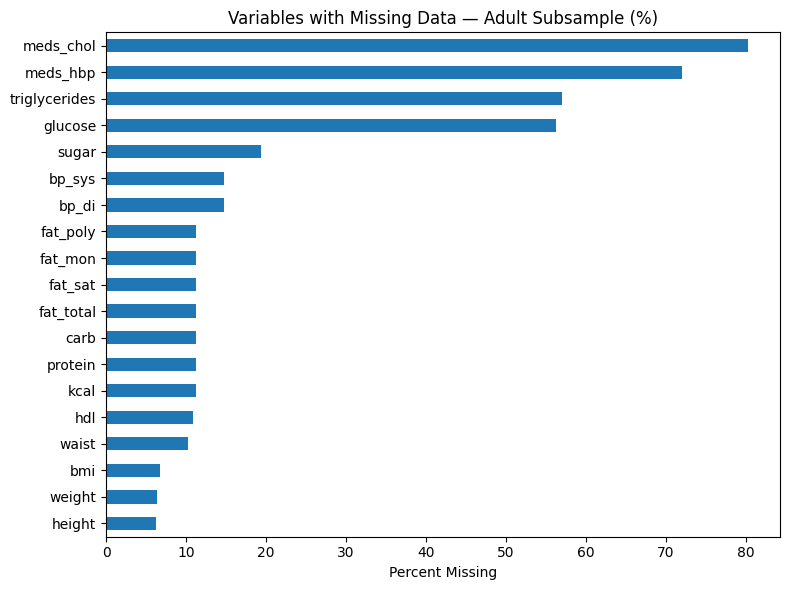

In [8]:
import matplotlib.pyplot as plt

missing_pct = df_adults.isna().mean().mul(100).sort_values(ascending=False).round(1)
print("Percent missing by variable (adults only):")
print(missing_pct.to_string())

missing_pct[missing_pct > 0].plot.barh(
    figsize=(8, 6),
    title="Variables with Missing Data — Adult Subsample (%)"
)
plt.gca().invert_yaxis()
plt.xlabel("Percent Missing")
plt.tight_layout()
plt.show()

---
## Section 9: Restrict to Complete Fasting and Dietary Records

Fasting laboratory values (`glucose`, `hdl`, `triglycerides`) are only collected from the
fasting subsample; their absence is by survey design and is not missing at random.
Dietary recall values are similarly non-random in their missingness, and NHANES guidance
advises against imputing 24-hour recall data. Both sets of variables are handled by
listwise deletion.

In [9]:
fasting_vars = ["glucose", "hdl", "triglycerides"]
diet_vars    = ["kcal", "protein", "carb", "fat_total",
                "fat_sat", "fat_mon", "fat_poly", "sugar"]

complete_mask = df_adults[fasting_vars + diet_vars].notna().all(axis=1)
df_complete   = df_adults.loc[complete_mask].copy()

print(f"Adults with complete fasting + dietary data: {len(df_complete):,} of {len(df_adults):,} "
      f"({len(df_complete) / len(df_adults):.1%})")
print(f"\nRows by survey cycle:")
print(df_complete.groupby("cycle_begin_year").size())

Adults with complete fasting + dietary data: 21,849 of 59,204 (36.9%)

Rows by survey cycle:
cycle_begin_year
2001    2501
2003    2295
2005    2299
2007    2624
2009    2807
2011    2363
2013    2463
2015    2227
2017    2270
dtype: int64


---
## Section 10: Impute Anthropometric and Blood Pressure Variables

Anthropometric measurements (`weight`, `height`, `bmi`, `waist`) and blood pressure
(`bp_sys`, `bp_di`) are missing due to random attendance or measurement failure and
are suitable for imputation. We use multiple imputation via scikit-learn's
`IterativeImputer` (a MICE-equivalent approach), conditioning on age, gender, survey
cycle, and the other variables in the imputation set.

An `imputed_*` boolean flag is added for each variable to record which values were filled.

In [10]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

impute_vars = ["weight", "height", "bmi", "waist", "bp_sys", "bp_di"]
predictors  = ["age", "gender", "cycle_begin_year"] + impute_vars

missing_cols = [c for c in predictors if c not in df_complete.columns]
if missing_cols:
    raise KeyError(f"Missing columns required for imputation: {missing_cols}")

# Reset index so that position-based assignment is safe after upstream filtering
df = df_complete.reset_index(drop=True).copy()

# Build the imputation matrix (IterativeImputer requires fully numeric input)
sub = df[predictors].copy()
sub["gender"] = sub["gender"].map({"male": 0, "female": 1})
if sub["gender"].isna().any():
    mode_val = 1 if (sub["gender"].mean(skipna=True) >= 0.5) else 0
    sub["gender"] = sub["gender"].fillna(mode_val)

# Fit imputation model and reconstruct DataFrame
imp           = IterativeImputer(random_state=42, max_iter=30)
imputed_array = imp.fit_transform(sub)
imputed_df    = pd.DataFrame(imputed_array, columns=sub.columns, index=sub.index)
imputed_df["gender"] = imputed_df["gender"].round().map({0: "male", 1: "female"})

# Merge imputed values back; record which rows were originally missing
df_imputed = df.copy()
for v in impute_vars:
    was_missing       = df[v].isna()
    df_imputed[v]     = imputed_df[v]
    df_imputed[f"imputed_{v}"] = was_missing

# Confirm all missing values were resolved
post_missing = df_imputed[impute_vars].isna().sum()
print("Missing values after imputation (all should be 0):")
print(post_missing)
assert int(post_missing.sum()) == 0, "Imputation did not resolve all missing values."
print("\nImputation complete.")

Missing values after imputation (all should be 0):
weight    0
height    0
bmi       0
waist     0
bp_sys    0
bp_di     0
dtype: int64

Imputation complete.


---
## Section 11: Filter Implausible Values and Derive Outcome Variables

Before deriving outcomes, one data quality filter is applied: diastolic BP values ≤ 1 mmHg
are removed as physiologically implausible (these arise from data entry errors or
measurement artifacts in the raw NHANES files).

Six binary outcome variables are then derived using established clinical thresholds:

| Variable | Definition | Source |
|---|---|---|
| `extreme_bp` | Systolic ≥ 130 mmHg **or** diastolic ≥ 80 mmHg | AHA/ACC 2017 Stage 1 hypertension |
| `extreme_waist` | Waist ≥ 102 cm (male) or ≥ 88 cm (female) | ATP III abdominal obesity criterion |
| `extreme_hdl` | HDL < 40 mg/dL (male) or < 50 mg/dL (female) | ATP III low HDL criterion |
| `extreme_tri` | Triglycerides ≥ 150 mg/dL | ATP III elevated triglycerides criterion |
| `extreme_glu` | Fasting glucose ≥ 100 mg/dL | ADA impaired fasting glucose threshold |
| `metsyn` | ≥ 3 of the above 5 criteria met | ATP III metabolic syndrome definition |

In [11]:
df_final = df_imputed.copy()

# Remove physiologically implausible diastolic BP values (near-zero data artifacts)
n_before  = len(df_final)
df_final  = df_final[df_final["bp_di"] > 1].copy()
n_removed = n_before - len(df_final)
print(f"Rows removed (bp_di <= 1 mmHg): {n_removed}")

# Elevated blood pressure (AHA/ACC 2017 Stage 1 hypertension threshold)
df_final["extreme_bp"] = (
    (df_final["bp_sys"] >= 130) | (df_final["bp_di"] >= 80)
)

# Abdominal obesity (ATP III waist circumference, sex-specific thresholds)
# Males: >= 102 cm | Females: >= 88 cm
df_final["extreme_waist"] = np.where(
    df_final["gender"] == "male",
    df_final["waist"] >= 102,
    df_final["waist"] >= 88
)

# Low HDL cholesterol (ATP III, sex-specific thresholds)
# Males: < 40 mg/dL | Females: < 50 mg/dL
df_final["extreme_hdl"] = np.where(
    df_final["gender"] == "male",
    df_final["hdl"] < 40,
    df_final["hdl"] < 50
)

# Elevated triglycerides (ATP III threshold)
df_final["extreme_tri"] = df_final["triglycerides"] >= 150

# Elevated fasting glucose (ADA impaired fasting glucose threshold)
df_final["extreme_glu"] = df_final["glucose"] >= 100

# Metabolic syndrome: 3 or more of the 5 ATP III component criteria are met
component_sum = (
    df_final["extreme_bp"].astype(int)
    + df_final["extreme_waist"].astype(int)
    + df_final["extreme_hdl"].astype(int)
    + df_final["extreme_tri"].astype(int)
    + df_final["extreme_glu"].astype(int)
)
df_final["metsyn"] = component_sum >= 3

# Summary
print(f"\nFinal dataset: {len(df_final):,} rows\n")
print("Derived variable prevalence:")
for col in ["extreme_bp", "extreme_waist", "extreme_hdl", "extreme_tri", "extreme_glu", "metsyn"]:
    n   = int(df_final[col].sum())
    pct = df_final[col].mean() * 100
    print(f"  {col:<16}  {n:>6,}  ({pct:.1f}%)")

Rows removed (bp_di <= 1 mmHg): 119

Final dataset: 21,730 rows

Derived variable prevalence:
  extreme_bp         8,599  (39.6%)
  extreme_waist     11,964  (55.1%)
  extreme_hdl        6,141  (28.3%)
  extreme_tri        5,947  (27.4%)
  extreme_glu       10,537  (48.5%)
  metsyn             7,703  (35.4%)


---
## Section 12: Data Quality Validation

Before export, we verify schema completeness, plausible value ranges, BMI internal
consistency, the diastolic BP filter, and row counts by survey cycle.

In [12]:
df_check = df_final.copy()
print(f"[INFO] Dataset: {len(df_check):,} rows, {len(df_check.columns)} columns\n")

# 1. Schema check
expected_cols = [
    "SEQN", "cycle_begin_year", "age", "gender",
    "bp_sys", "bp_di", "weight", "height", "bmi", "waist",
    "kcal", "protein", "sugar", "carb",
    "fat_total", "fat_sat", "fat_mon", "fat_poly",
    "hdl", "glucose", "triglycerides",
    "meds_hbp", "meds_chol",
    "imputed_weight", "imputed_height", "imputed_bmi",
    "imputed_waist", "imputed_bp_sys", "imputed_bp_di",
    "extreme_bp", "extreme_waist", "extreme_hdl",
    "extreme_tri", "extreme_glu", "metsyn",
]
missing_cols = [c for c in expected_cols if c not in df_check.columns]
if missing_cols:
    print(f"[FAIL] Missing columns: {missing_cols}")
else:
    print(f"[PASS] All {len(expected_cols)} expected columns present")

# 2. Coerce numeric types for range checks
num_cols = ["age", "weight", "height", "bmi", "waist", "bp_sys", "bp_di",
            "kcal", "protein", "carb", "fat_total", "fat_sat", "fat_mon",
            "fat_poly", "sugar", "glucose", "hdl", "triglycerides"]
for c in num_cols:
    if c in df_check.columns:
        df_check[c] = pd.to_numeric(df_check[c], errors="coerce")

# 3. Plausibility range checks
range_checks = [
    ("age",           18,  100), ("height",  120,  210),
    ("weight",        35,  250), ("bmi",      12,   70),
    ("waist",         40,  200), ("bp_sys",   70,  240),
    ("bp_di",          1,  140), ("kcal",    400, 7000),
    ("protein",        5,  400), ("carb",     10, 1000),
    ("fat_total",      5,  500), ("glucose",  40,  400),
    ("hdl",           10,  150), ("triglycerides", 20, 2000),
]
out_of_range = []
for col, lo, hi in range_checks:
    if col in df_check.columns:
        x     = df_check[col].dropna()
        n_bad = int(((x < lo) | (x > hi)).sum())
        if n_bad > 0:
            out_of_range.append((col, n_bad, lo, hi))
if out_of_range:
    print("[WARN] Out-of-range values (review before interpreting):")
    for col, n_bad, lo, hi in out_of_range:
        print(f"   {col:<14} {n_bad:>5} outside [{lo}, {hi}]")
else:
    print("[PASS] All core variables within expected ranges")

# 4. Diastolic BP filter confirmation
n_implausible = int((df_check["bp_di"] <= 1).sum())
if n_implausible > 0:
    print(f"[FAIL] {n_implausible} row(s) with bp_di <= 1 still present")
else:
    print("[PASS] No implausible diastolic BP values (bp_di <= 1)")

# 5. BMI internal consistency
if {"weight", "height"}.issubset(df_check.columns):
    bmi_calc = df_check["weight"] / (df_check["height"] / 100.0) ** 2
    corr     = df_check["bmi"].corr(bmi_calc)
    status   = "PASS" if corr >= 0.995 else "WARN"
    print(f"[{status}] BMI correlation with weight/height: r = {corr:.4f}")

# 6. Row counts by survey cycle
print("\n[INFO] Rows by survey cycle:")
print(df_check.groupby("cycle_begin_year").size().to_string())

# 7. Derived variable prevalence
print("\n[INFO] Derived variable prevalence:")
for col in ["extreme_bp", "extreme_waist", "extreme_hdl", "extreme_tri", "extreme_glu", "metsyn"]:
    if col in df_check.columns:
        print(f"  {col:<16} {df_check[col].mean() * 100:.1f}%")

[INFO] Dataset: 21,730 rows, 35 columns

[PASS] All 35 expected columns present
[WARN] Out-of-range values (review before interpreting):
   weight             5 outside [35, 250]
   bmi                7 outside [12, 70]
   waist              3 outside [40, 200]
   bp_sys             1 outside [70, 240]
   kcal             151 outside [400, 7000]
   protein           45 outside [5, 400]
   carb              38 outside [10, 1000]
   fat_total         56 outside [5, 500]
   glucose           31 outside [40, 400]
   hdl                8 outside [10, 150]
   triglycerides     25 outside [20, 2000]
[PASS] No implausible diastolic BP values (bp_di <= 1)
[PASS] BMI correlation with weight/height: r = 0.9999

[INFO] Rows by survey cycle:
cycle_begin_year
2001    2488
2003    2277
2005    2280
2007    2605
2009    2801
2011    2356
2013    2450
2015    2214
2017    2259

[INFO] Derived variable prevalence:
  extreme_bp       39.6%
  extreme_waist    55.1%
  extreme_hdl      28.3%
  extreme_tri  

---
## Section 13: Export Final Dataset

The final dataset is written to `MLforNutrition_NHANES.csv` in the same directory as
this notebook. This file is the single data source for all tutorials in the repository.

In [13]:
# Final column order for the output file
output_col_order = [
    # Identifiers
    "SEQN", "cycle_begin_year",
    # Demographics
    "age", "gender",
    # Anthropometrics and blood pressure
    "bp_sys", "bp_di", "weight", "height", "bmi", "waist",
    # Dietary intake (Day 1 24-hour recall)
    "kcal", "protein", "sugar", "carb",
    "fat_total", "fat_sat", "fat_mon", "fat_poly",
    # Fasting laboratory measures
    "hdl", "glucose", "triglycerides",
    # Medications
    "meds_hbp", "meds_chol",
    # Imputation flags
    "imputed_weight", "imputed_height", "imputed_bmi",
    "imputed_waist",  "imputed_bp_sys", "imputed_bp_di",
    # Derived outcome variables
    "extreme_bp", "extreme_waist", "extreme_hdl",
    "extreme_tri", "extreme_glu", "metsyn",
]

df_output = df_final[[c for c in output_col_order if c in df_final.columns]]

missing_out = [c for c in output_col_order if c not in df_output.columns]
if missing_out:
    print(f"WARNING: Missing expected columns in output: {missing_out}")

output_path = "MLforNutrition_NHANES.csv"
df_output.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Rows:  {len(df_output):,}")
print(f"Cols:  {len(df_output.columns)}  {list(df_output.columns)}")

Saved: MLforNutrition_NHANES.csv
Rows:  21,730
Cols:  35  ['SEQN', 'cycle_begin_year', 'age', 'gender', 'bp_sys', 'bp_di', 'weight', 'height', 'bmi', 'waist', 'kcal', 'protein', 'sugar', 'carb', 'fat_total', 'fat_sat', 'fat_mon', 'fat_poly', 'hdl', 'glucose', 'triglycerides', 'meds_hbp', 'meds_chol', 'imputed_weight', 'imputed_height', 'imputed_bmi', 'imputed_waist', 'imputed_bp_sys', 'imputed_bp_di', 'extreme_bp', 'extreme_waist', 'extreme_hdl', 'extreme_tri', 'extreme_glu', 'metsyn']
